In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from src.data_loader import load_processed
from src.models import train_arima, create_sequences, build_lstm, recursive_forecast
from src.evaluate import evaluate_forecast

In [2]:
tsla = load_processed("TSLA")

train = tsla[tsla.index < "2025-01-01"]
test = tsla[tsla.index >= "2025-01-01"]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} rows)")
print(f"Test: {test.index.min()} to {test.index.max()} ({len(test)} rows)")

Train: 2015-01-02 00:00:00 to 2024-12-31 00:00:00 (2516 rows)
Test: 2025-01-02 00:00:00 to 2026-06-29 00:00:00 (372 rows)


In [3]:
arima_model = train_arima(train["Adj Close"])
print(arima_model.summary())

n_periods = len(test)
arima_forecast, arima_conf_int = arima_model.predict(n_periods=n_periods, return_conf_int=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Fri, 03 Jul 2026   AIC                          16368.109
Time:                        11:46:42   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Pr

c:\Users\acer\Downloads\10 Acadamy\projects\Week_9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\acer\Downloads\10 Acadamy\projects\Week_9\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


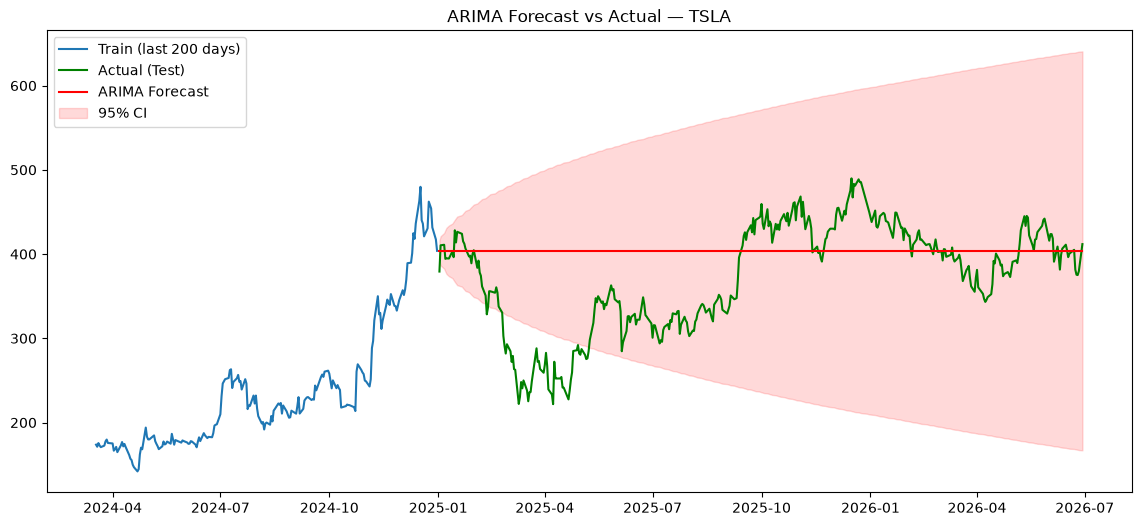

In [4]:
plt.figure(figsize=(14,6))
plt.plot(train.index[-200:], train["Adj Close"][-200:], label="Train (last 200 days)")
plt.plot(test.index, test["Adj Close"], label="Actual (Test)", color="green")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast", color="red")
plt.fill_between(test.index, arima_conf_int[:, 0], arima_conf_int[:, 1], color="red", alpha=0.15, label="95% CI")
plt.legend()
plt.title("ARIMA Forecast vs Actual — TSLA")
plt.show()

In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[["Adj Close"]])
test_scaled = scaler.transform(test[["Adj Close"]])

window_size = 60
X_train, y_train = create_sequences(train_scaled, window_size)

combined = np.concatenate([train_scaled[-window_size:], test_scaled])
X_test, y_test = create_sequences(combined, window_size)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape, X_test.shape)

(2456, 60, 1) (372, 60, 1)


In [6]:
model_lstm = build_lstm(window_size)
model_lstm.summary()

history = model_lstm.fit(
    X_train, y_train,
    epochs=20, batch_size=32,
    validation_split=0.1, verbose=1
)

c:\Users\acer\Downloads\10 Acadamy\projects\Week_9\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0065 - val_loss: 0.0030
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0016 - val_loss: 0.0027
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0016 - val_loss: 0.0024
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0014 - val_loss: 0.0028
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0010 - val_loss: 0.0019
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 9.6593e-04 - val_loss: 0.0026
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 9.4415e-04 - val_loss: 0.0040
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 8.8660e-04 - val_loss: 0.0020
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step

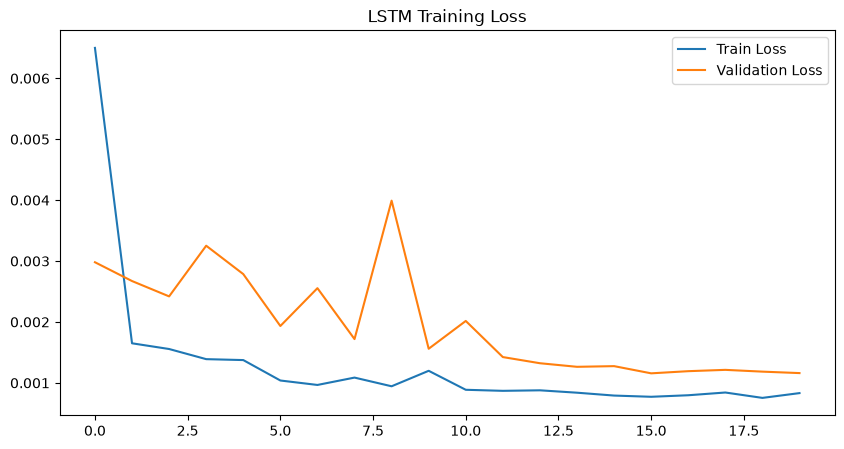

In [7]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("LSTM Training Loss")
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


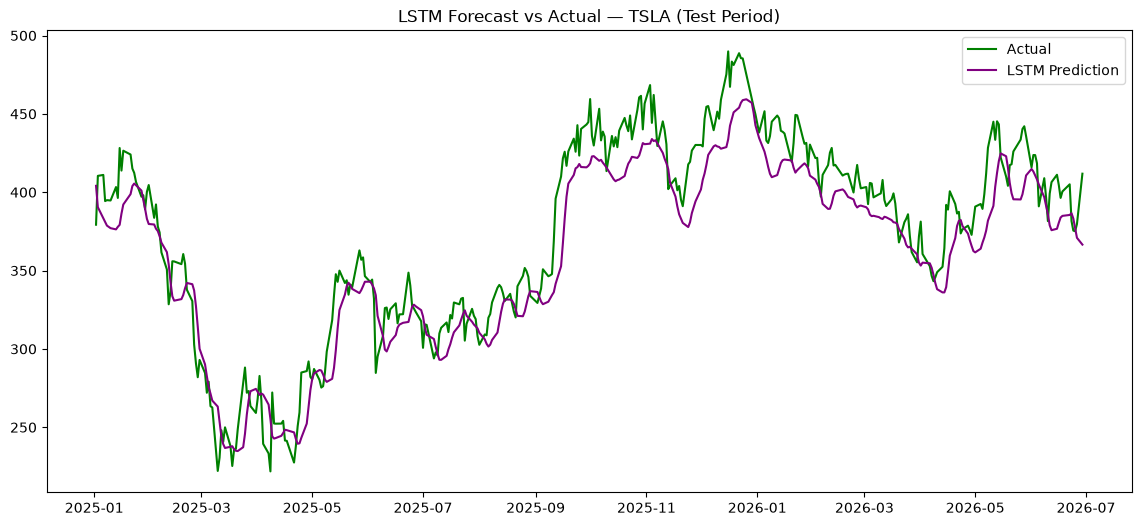

In [8]:
predictions_scaled = model_lstm.predict(X_test)
predictions = scaler.inverse_transform(predictions_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14,6))
plt.plot(test.index, actual, label="Actual", color="green")
plt.plot(test.index, predictions, label="LSTM Prediction", color="purple")
plt.legend()
plt.title("LSTM Forecast vs Actual — TSLA (Test Period)")
plt.show()

In [9]:
arima_metrics = evaluate_forecast(test["Adj Close"].values, arima_forecast)
lstm_metrics = evaluate_forecast(actual.flatten(), predictions.flatten())

print("ARIMA:", arima_metrics)
print("LSTM: ", lstm_metrics)

ARIMA: {'mae': 54.44118233137233, 'rmse': np.float64(70.53934610418263), 'mape': np.float64(17.240653410477236)}
LSTM:  {'mae': 17.70927129765993, 'rmse': np.float64(21.813865782662674), 'mape': np.float64(4.726505011807186)}
